<h1 align="center"><font color="red">Data Analysis and Visualization</font></h1>
<center><h2><font color="green">CHAPTER 3: Dashboarding with Python</font></h2></center>

<center align="left">Ala-Too International University</center>
<center align="left"><b>Instructor: Dr. Remudin Reshid Mekuria</b></center>

---

<div style="border: 2px solid #1b5e20; padding: 16px; border-radius: 10px; background-color: #f1f8e9;">
<h3 style="color:#1b5e20;"></h3>

This chapter is designed as a <b>full teaching notebook</b> of dashboarding for the course <b>Data Analysis and Visualization</b>.  
It treats dashboarding not simply as a software topic, but as a blend of:

<ul>
<li><b>analytical reasoning</b>,</li>
<li><b>visual design</b>,</li>
<li><b>audience awareness</b>,</li>
<li><b>communication discipline</b>,</li>
<li><b>and practical implementation</b>.</li>
</ul>

The chapter guides students from:
<ul>
<li>understanding what dashboards are,</li>
<li>to evaluating dashboard quality,</li>
<li>to building static and interactive dashboards,</li>
<li>to planning a meaningful mini-project for real users.</li>
</ul>
</div>

## Chapter Learning Outcomes

By the end of this chapter, students should be able to:

1. Define dashboarding as an analytical communication task.
2. Distinguish among operational, analytical, and strategic dashboards.
3. Explain core dashboard design principles and common design failures.
4. Select useful KPIs for a dashboard audience.
5. Build a static dashboard using Matplotlib subplots.
6. Build an interactive dashboard using Plotly subplots.
7. Explain the role of Streamlit in lightweight dashboard deployment.
8. Combine metrics, charts, filters, and tables into a coherent layout.
9. Critically evaluate the quality of a dashboard.
10. Produce a mini dashboard project with interpretation and reporting.

## Chapter Structure

- **03.00** Introduction to Dashboarding  
- **03.01** What is a Dashboard?  
- **03.02** Principles of Effective Dashboard Design  
- **03.03** Key Performance Indicators (KPIs)  
- **03.04** Building Simple Dashboards with Matplotlib  
- **03.05** Interactive Dashboarding with Plotly  
- **03.06** Dashboard Layouts with Streamlit (Intro)  
- **03.07** Dashboard Components: Filters, Metrics, Charts, Tables  
- **03.08** Dashboard Critique and Improvement  
- **03.09** Mini Dashboard Project  
- **03.10** Exercises and Reflection

# 03.00 Introduction to Dashboarding

In earlier chapters, students learned how to clean data and create individual visualizations.
That was the necessary first step.

However, real users often do not want:
- one plot,
- one table,
- and one statistic at a time.

They want a <b>single analytical view</b> that allows them to answer several related questions quickly.

That is the role of a dashboard.

A dashboard is therefore not just a technical output.
It is a practical tool for:
- monitoring,
- comparison,
- interpretation,
- and decision support.

In this chapter, students move from
<b>“making charts”</b>  
to  
<b>“designing analytical interfaces.”</b>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

np.random.seed(42)

<div style="border-left: 6px solid #1565c0; padding: 10px; background-color: #e3f2fd;">
<b>Instructor Note</b><br>
Students should repeatedly be reminded that a dashboard is not “many visuals on one page.”
A stronger definition is:
<b>a coordinated analytical layout designed to help a specific audience answer specific questions efficiently.</b>
</div>

# 03.01 What is a Dashboard?

A dashboard is a structured visual interface that combines:

- KPI summaries,
- charts,
- tables,
- and sometimes filters or controls

into one integrated analytical page.

The purpose is not decoration.
The purpose is to help a user understand the state of a system, compare categories, and identify points that require attention.

## Dashboard vs Single Visualization

A single chart usually answers one question.

A dashboard usually answers a <b>set of connected questions</b>.

For example, a student performance dashboard might answer:
- What is the average score?
- What is the pass rate?
- Which department performs best?
- Does attendance appear related to final score?
- Are there groups that need intervention?

## Types of Dashboards

### 1. Operational Dashboards
Used for short-term or real-time monitoring.

### 2. Analytical Dashboards
Used for deeper exploration and explanation.

### 3. Strategic Dashboards
Used for summary-level decision-making and management reporting.

## Example Domains

Dashboards are common in:
- education,
- business,
- healthcare,
- finance,
- digital platforms,
- environmental monitoring,
- and scientific operations.

<div style="border-left: 6px solid #ff9800; padding: 10px; background-color: #fff8e1;">
<b>Reflection Pause 1</b><br>
Why might a department chair, hospital administrator, or business manager prefer a dashboard over a long report with separate charts?
What kind of decisions become easier with a dashboard?
</div>

# 03.02 Principles of Effective Dashboard Design

A dashboard should not only be informative.
It should also be:
- readable,
- selective,
- balanced,
- and purposeful.

## Core Design Principles

### 1. Clarity
The user should understand the purpose of the dashboard quickly.

### 2. Relevance
Each element should answer a useful question.

### 3. Simplicity
Avoid clutter, unnecessary decoration, and irrelevant visual elements.

### 4. Consistency
Use consistent scales, color meanings, labels, and layout style.

### 5. Hierarchy
Put the most important information first.

### 6. Comparability
Enable meaningful comparison between categories, time periods, or groups.

### 7. Actionability
A strong dashboard helps the user know what deserves attention next.

## Common Dashboard Mistakes

- too many charts,
- tiny unreadable labels,
- unclear titles,
- inconsistent axis scales,
- excessive colors,
- mixing unrelated metrics,
- poor spacing,
- placing minor information where major information should be,
- or choosing charts that do not match the analytical question.

<div style="border-left: 6px solid #b71c1c; padding: 10px; background-color: #ffebee;">
<b>Common Mistake Box</b><br>
Students often think “more visuals = better dashboard.”
In practice, the opposite is often true:
<b>too much content reduces analytical clarity.</b>
The strongest dashboards are selective and disciplined.
</div>

## Quick Design Checklist

Before finalizing a dashboard, ask:
- What is the main analytical purpose?
- Who is the intended audience?
- Which KPIs matter most?
- Which charts are essential?
- What can be removed without losing meaning?

# 03.03 Key Performance Indicators (KPIs)

KPIs are high-value summary numbers that communicate important outcomes quickly.

Examples include:
- average score,
- pass rate,
- total students,
- average attendance,
- total sales,
- average waiting time,
- monthly visitors.

In [9]:
# Realistic synthetic academic dataset
n = 140
departments = np.random.choice(["CS", "Math", "Physics", "Data Science"], size=n, p=[0.30, 0.22, 0.20, 0.28])
gender = np.random.choice(["Male", "Female"], size=n)
hours = np.random.normal(6.5, 1.8, n).clip(1, 12)
attendance = np.random.normal(84, 8, n).clip(55, 100)
assignments = np.random.normal(78, 10, n).clip(40, 100)
final_exam = (30 + 3.1*hours + 0.22*attendance + 0.18*assignments + np.random.normal(0, 7, n)).clip(0, 100)

dash_df = pd.DataFrame({
    "department": departments,
    "gender": gender,
    "hours_studied": hours.round(1),
    "attendance_rate": attendance.round(1),
    "assignment_score": assignments.round(1),
    "final_score": final_exam.round(1)
})

dash_df["pass_fail"] = np.where(dash_df["final_score"] >= 50, "Pass", "Fail")
dash_df.head()

,department,gender,hours_studied,attendance_rate,assignment_score,final_score,pass_fail
0,Math,Female,9.9,91.2,94.3,99.2,Pass
1,Data Science,Female,7.4,86.5,64.2,88.8,Pass
2,Data Science,Female,4.4,90.5,61.0,64.0,Pass
3,Physics,Male,7.7,89.0,77.4,95.3,Pass
4,CS,Female,4.7,77.4,81.8,78.8,Pass


In [10]:
avg_score = dash_df["final_score"].mean()
pass_rate = (dash_df["pass_fail"] == "Pass").mean() * 100
avg_attendance = dash_df["attendance_rate"].mean()
avg_assignment = dash_df["assignment_score"].mean()
student_count = len(dash_df)

print("Average Score:", round(avg_score, 2))
print("Pass Rate (%):", round(pass_rate, 2))
print("Average Attendance:", round(avg_attendance, 2))
print("Average Assignment Score:", round(avg_assignment, 2))
print("Student Count:", student_count)

Average Score: 82.79
Pass Rate (%): 100.0
Average Attendance: 84.94
Average Assignment Score: 76.29
Student Count: 140


## Why KPI Choice Matters

KPIs should not be selected randomly.

A strong KPI is:
- important to the audience,
- easy to understand,
- and meaningful for monitoring or decision-making.

For this dataset:
- **Average score** summarizes overall performance.
- **Pass rate** summarizes success level.
- **Average attendance** captures engagement.
- **Average assignment score** reflects continuous assessment.
- **Student count** gives context.

<div style="border-left: 6px solid #2e7d32; padding: 10px; background-color: #e8f5e9;">
<b>Instructor Tip</b><br>
A beginner dashboard usually works best with <b>3 to 5 KPIs</b>.
Too few may be incomplete; too many may weaken the hierarchy.
</div>

# 03.04 Building Simple Dashboards with Matplotlib

Matplotlib subplots provide a strong starting point for dashboarding because they teach:
- layout discipline,
- role differentiation between charts,
- and static dashboard thinking.

This is especially useful for:
- reports,
- teaching notebooks,
- static presentation slides,
- and first dashboard assignments.

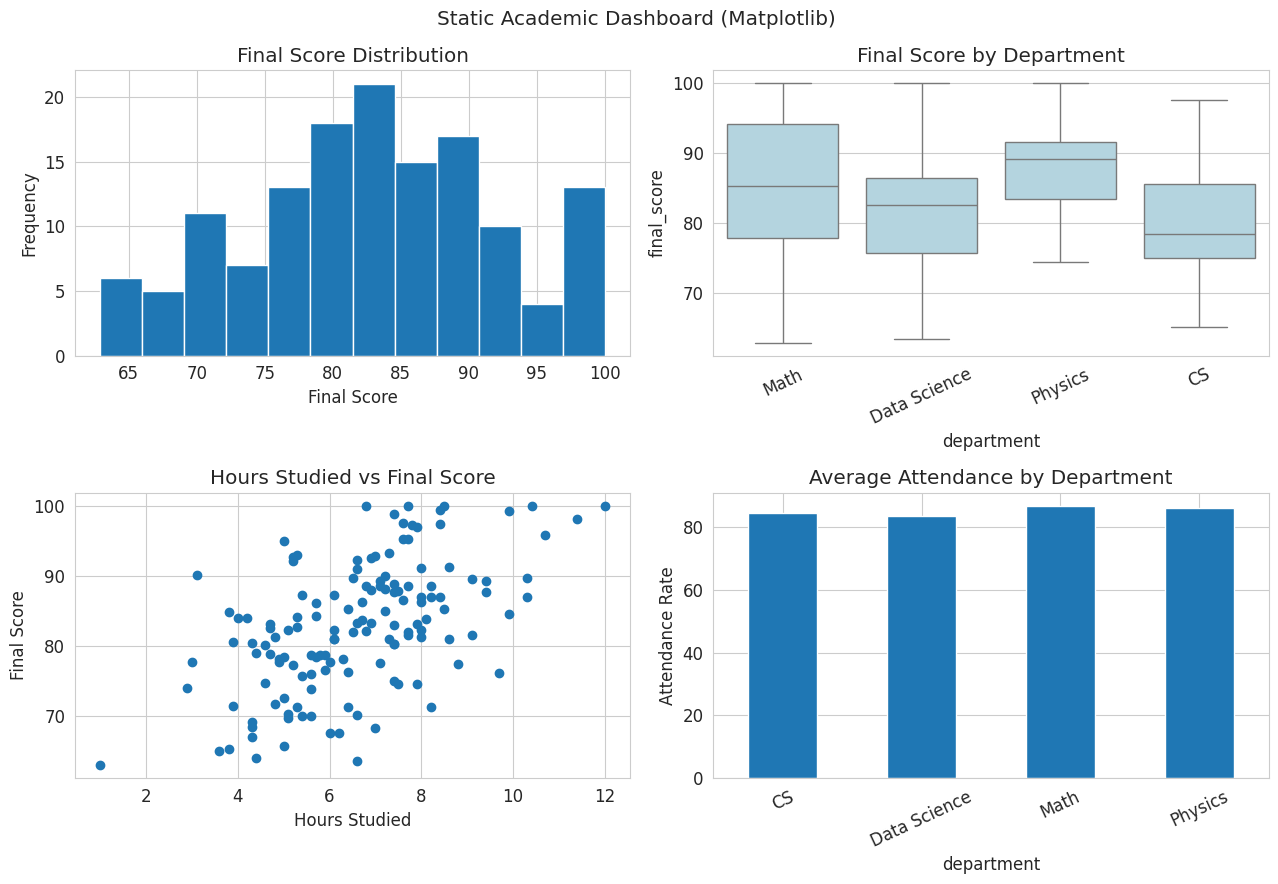

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Histogram
axes[0, 0].hist(dash_df["final_score"], bins=12)
axes[0, 0].set_title("Final Score Distribution")
axes[0, 0].set_xlabel("Final Score")
axes[0, 0].set_ylabel("Frequency")

# Boxplot by department
sns.boxplot(x="department", y="final_score", data=dash_df, ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Final Score by Department")
axes[0, 1].tick_params(axis="x", rotation=25)

# Scatter plot
axes[1, 0].scatter(dash_df["hours_studied"], dash_df["final_score"])
axes[1, 0].set_title("Hours Studied vs Final Score")
axes[1, 0].set_xlabel("Hours Studied")
axes[1, 0].set_ylabel("Final Score")

# Bar chart
dept_att = dash_df.groupby("department")["attendance_rate"].mean()
dept_att.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Average Attendance by Department")
axes[1, 1].set_ylabel("Attendance Rate")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.suptitle("Static Academic Dashboard (Matplotlib)")
plt.tight_layout()
plt.show()

## Why this static dashboard works

This layout combines:
- a **distribution** view,
- a **group comparison** view,
- a **relationship** view,
- and a **summary comparison** view.

That makes it stronger than a dashboard that repeats the same chart type four times.

## Classroom Discussion Prompt

If you had to remove one chart from this dashboard, which one would you remove and why?  
If you had to add one more useful chart, what would it be?

# 03.05 Interactive Dashboarding with Plotly

Plotly adds interactivity to dashboards through:
- hover details,
- zooming,
- legend control,
- and browser-friendly rendering.

This is especially important when dashboards are used in exploratory settings.

In [ ]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Score Distribution", "Department Average Score",
                    "Hours Studied vs Final Score", "Pass / Fail Counts")
)

# Histogram
fig.add_trace(
    go.Histogram(x=dash_df["final_score"], name="Final Score"),
    row=1, col=1
)

# Bar chart
dept_score = dash_df.groupby("department")["final_score"].mean().reset_index()
fig.add_trace(
    go.Bar(x=dept_score["department"], y=dept_score["final_score"], name="Department Avg"),
    row=1, col=2
)

# Scatter
fig.add_trace(
    go.Scatter(
        x=dash_df["hours_studied"],
        y=dash_df["final_score"],
        mode="markers",
        name="Study vs Score"
    ),
    row=2, col=1
)

# Pass/fail
pf = dash_df["pass_fail"].value_counts().reset_index()
pf.columns = ["status", "count"]
fig.add_trace(
    go.Bar(x=pf["status"], y=pf["count"], name="Pass/Fail"),
    row=2, col=2
)

fig.update_layout(height=760, width=1050, title_text="Interactive Academic Dashboard (Plotly)")
fig.show()

## Why Plotly is pedagogically valuable

Plotly helps students see that dashboarding in modern settings is often:
- exploratory,
- interactive,
- and intended for web-like presentation rather than static output only.

This is an important bridge from visualization notebooks to real-world dashboard practice.

# 03.06 Dashboard Layouts with Streamlit (Intro)

Streamlit is a beginner-friendly framework for turning Python analysis into a browser-based dashboard.

A Streamlit app can include:
- KPI cards,
- charts,
- tables,
- filters,
- dropdown controls,
- sliders,
- and explanatory text.

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px

st.title("Academic Performance Dashboard")

df = pd.DataFrame({
    "department": ["CS", "Math", "Physics", "Data Science"],
    "avg_score": [74, 69, 72, 79],
    "pass_rate": [88, 82, 84, 91]
})

selected_metric = st.selectbox("Select metric", ["avg_score", "pass_rate"])

st.metric("Overall Average Score", round(df["avg_score"].mean(), 2))
st.metric("Overall Pass Rate", round(df["pass_rate"].mean(), 2))

fig = px.bar(df, x="department", y=selected_metric, title=f"Department {selected_metric}")
st.plotly_chart(fig)

st.dataframe(df)
'''
print(streamlit_code)


import streamlit as st
import pandas as pd
import plotly.express as px

st.title("Academic Performance Dashboard")

df = pd.DataFrame({
    "department": ["CS", "Math", "Physics", "Data Science"],
    "avg_score": [74, 69, 72, 79],
    "pass_rate": [88, 82, 84, 91]
})

selected_metric = st.selectbox("Select metric", ["avg_score", "pass_rate"])

st.metric("Overall Average Score", round(df["avg_score"].mean(), 2))
st.metric("Overall Pass Rate", round(df["pass_rate"].mean(), 2))

fig = px.bar(df, x="department", y=selected_metric, title=f"Department {selected_metric}")
st.plotly_chart(fig)

st.dataframe(df)



## How to run the app

1. Save the code as `app.py`
2. Open a terminal
3. Run:

```bash
streamlit run app.py
```

The result will open in a browser.

<div style="border-left: 6px solid #6a1b9a; padding: 10px; background-color: #f3e5f5;">
<b>Pedagogical Note</b><br>
At this stage, students do not need advanced deployment skills.
The main goal is to understand:
<ul>
<li>component structure,</li>
<li>dashboard layout,</li>
<li>and user interaction concepts.</li>
</ul>
</div>

# 03.07 Dashboard Components: Filters, Metrics, Charts, Tables

A good dashboard is usually built from four coordinated component types.

## 1. Metrics
High-priority summary values.

## 2. Charts
Show:
- comparisons,
- distributions,
- trends,
- and relationships.

## 3. Tables
Provide detail when exact values matter.

## 4. Filters
Allow the user to narrow the analysis by category, department, region, time period, or group.

In [ ]:
# Simple filtering example
filtered_ds = dash_df[dash_df["department"] == "Data Science"]
filtered_ds.head()

,department,gender,hours_studied,attendance_rate,assignment_score,final_score,pass_fail
1,Data Science,Female,7.4,86.5,64.2,88.8,Pass
2,Data Science,Female,4.4,90.5,61.0,64.0,Pass
7,Data Science,Male,5.0,88.9,77.1,94.9,Pass
11,Data Science,Male,9.9,79.3,68.6,84.6,Pass
12,Data Science,Male,6.1,88.4,72.9,87.2,Pass


In [ ]:
print("Average score for Data Science:", round(filtered_ds["final_score"].mean(), 2))
print("Pass rate for Data Science:", round((filtered_ds["pass_fail"] == "Pass").mean() * 100, 2))
print("Average attendance for Data Science:", round(filtered_ds["attendance_rate"].mean(), 2))

Average score for Data Science: 81.28
Pass rate for Data Science: 100.0
Average attendance for Data Science: 83.39


## Why filters matter

A filter transforms a dashboard from a fixed report into a flexible tool.

With filters, the same dashboard can answer:
- How is CS performing?
- How is Data Science performing?
- Does the relationship change for a selected group?
- Which subgroup needs attention?

# 03.08 Dashboard Critique and Improvement

A useful learning exercise is not only to build dashboards, but also to critique them.

## Ask the following questions:

1. Is the purpose of the dashboard clear?
2. Are the KPIs the right ones?
3. Are any charts redundant?
4. Are the chart types appropriate?
5. Is the layout balanced?
6. Is the text readable?
7. Can the user identify the most important insight quickly?

## Example Critique Prompt

Imagine a dashboard with:
- 8 charts,
- 4 different color schemes,
- small unreadable axis labels,
- and no KPI summaries.

### Questions
- What is wrong with the design?
- Which parts would you remove?
- What would you reorganize?
- Which KPI values should be added first?

<div style="border-left: 6px solid #ef6c00; padding: 10px; background-color: #fff3e0;">
<b>Design Improvement Tip</b><br>
When a dashboard feels weak, the solution is often not “add more.”
The solution is often:
<ul>
<li>remove clutter,</li>
<li>strengthen hierarchy,</li>
<li>make titles clearer,</li>
<li>and align each visual with one useful question.</li>
</ul>
</div>

# 03.09 Mini Dashboard Project

## Project Scenario

Create a dashboard for one of the following domains:

- student performance,
- healthcare monitoring,
- financial analytics,
- website traffic,
- air quality monitoring.

Your dashboard must include:

1. at least **4 KPI values**
2. at least **4 charts**
3. at least **1 detailed table**
4. at least **1 filter or grouping mechanism**
5. a short explanation of the intended audience
6. a final interpretation paragraph
7. at least one short critique of your own design

## Recommended Project Workflow

### Step 1: Choose the dataset
The dataset should contain:
- at least one numeric variable,
- at least one categorical variable,
- and at least one meaningful performance variable.

### Step 2: Define the audience
Examples:
- instructor,
- school administrator,
- doctor,
- manager,
- business analyst.

### Step 3: Define the key questions
Examples:
- What is the performance level?
- Which group is strongest?
- Is there a warning sign?
- What deserves further attention?

### Step 4: Select KPIs
Choose values that matter to the audience.

### Step 5: Choose charts
Include a useful mix of:
- distribution,
- comparison,
- relationship,
- and category summary views.

### Step 6: Build the layout
Put:
- KPIs first,
- major charts next,
- supporting details last.

### Step 7: Interpret
Write a paragraph explaining:
- what the dashboard shows,
- what stands out,
- and what the user should notice.

<div style="border: 2px solid #2e7d32; padding: 14px; border-radius: 10px; background-color: #e8f5e9;">
<h3 style="color:#1b5e20;">Mini Project Rubric</h3>

<ul>
<li><b>20%</b> KPI relevance and quality</li>
<li><b>20%</b> Appropriate chart selection</li>
<li><b>20%</b> Layout readability and dashboard structure</li>
<li><b>15%</b> Effective use of filters or grouping</li>
<li><b>15%</b> Interpretation quality</li>
<li><b>10%</b> Code clarity and reproducibility</li>
</ul>
</div>

# 03.10 Exercises and Reflection

## Exercise Set A: Conceptual (Easy)

1. What is the difference between a chart and a dashboard?
2. Why are KPIs important?
3. Why should dashboards avoid clutter?
4. Why does audience matter in dashboard design?
5. What is one reason filters improve dashboards?

## Exercise Set B: Practical (Moderate)

1. Compute 4 KPI values from a dataset of your choice.
2. Build a 2×2 static dashboard using Matplotlib.
3. Recreate two of the visuals in Plotly.
4. Apply one category-based filter.
5. Write a short paragraph explaining what the dashboard shows.

## Exercise Set C: Advanced (Hard)

1. Critique an existing dashboard design of your own.
2. Identify one chart that should be removed or replaced.
3. Justify why each KPI was selected.
4. Explain how the layout could be improved.
5. Sketch how the dashboard could be turned into a Streamlit app.

## Reflection Questions

- When does a dashboard become too crowded?
- Which is more important: visual attractiveness or analytical usefulness?
- What is the most common beginner mistake in dashboarding?
- How should dashboard design change for different audiences?

# Chapter Summary

This chapter moved beyond isolated plotting and introduced dashboarding as a more complete analytical practice.

Students learned that a dashboard is:
- not simply a set of charts,
- but a structured analytical interface for monitoring, comparison, and decision support.

They learned how to:
- define dashboards,
- distinguish dashboard types,
- apply design principles,
- choose meaningful KPIs,
- build static dashboards with Matplotlib,
- build interactive dashboards with Plotly,
- understand beginner deployment ideas with Streamlit,
- critique dashboard quality,
- and complete a meaningful dashboard project.

This chapter helps students move from:
<b>“I can make visualizations”</b>  
to  
<b>“I can design analytical views for real users.”</b>

<div style="border-left: 6px solid #1b5e20; padding: 12px; background-color: #f1f8e9;">
<b>Instructor’s Closing Note</b><br>
The best dashboard is not the one with the most charts.  
It is the one that helps the right user understand the right information at the right time.

That is the central lesson of dashboarding.
</div>